In [1]:
config_dir   = "/cluster/home/t144807uhn/chip-stroma-analysis/configs"
version      = "v6"
results_dir  = "/cluster/projects/kumargroup/sophia/chip-stroma-analysis/results"

In [56]:
import sys
import os
import logging

from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root / "src"))

os.chdir(Path.cwd().parent)

import wandb

import argparse as ap

from pathlib import Path

from chip_stroma.utils.header_footers import log_header, log_footer
from chip_stroma.utils.config import load_configs
from chip_stroma.utils.loggers import setup_logger
from chip_stroma.utils.io import (
    load_overlay_arrays, 
    load_csv_inputs,
    load_json,
    load_pickle
)

from chip_stroma.visualize.segmentation_plots import (
    plot_fold_boxplots,
    plot_pr_curve,
    plot_patient_dice_violin,
    plot_overlay_panel,
    plot_optuna_importance,
    plot_confusion_matrix,
    plot_dice_vs_vessel_area,
    plot_calibration
)

logger = setup_logger(__name__)
logging.getLogger("matplotlib.category").setLevel(logging.ERROR)

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [57]:
log_header(
    pipeline_stage = "Visualization",
    config_path    = Path(config_dir) / "09_visualize.yaml",
    version        = version 
)

# Load workflow and path configurations
config = load_configs(
    pipeline = Path(config_dir) / "09_visualize.yaml",
    paths    = Path(config_dir) / "00_paths.yaml"
)

# Initialize the version figure directory
evaluate_dir  = Path(config.paths.results) / version / "evaluate"
inference_dir = Path(config.paths.results) / version / "inference"
figure_dir    = Path(config.paths.figures) / version / "segmentation"
figure_dir.mkdir(parents = True, exist_ok = True) 

2026-07-30 19:23:50,203 | INFO     | utils.header_footers           | ============================================================
2026-07-30 19:23:50,204 | INFO     | utils.header_footers           | Starting Pipeline Execution
2026-07-30 19:23:50,205 | INFO     | utils.header_footers           | - Pipeline Stage    : Visualization
2026-07-30 19:23:50,205 | INFO     | utils.header_footers           | - Configurations    : t144807uhn/chip-stroma-analysis/configs/09_visualize.yaml
2026-07-30 19:23:50,206 | INFO     | utils.header_footers           | - Version           : v6
2026-07-30 19:23:50,206 | INFO     | utils.header_footers           | - Working Directory : /cluster/home
2026-07-30 19:23:50,207 | INFO     | utils.header_footers           | - Timestamp         : 2026-07-30 19:23:50
2026-07-30 19:23:50,207 | INFO     | utils.header_footers           | ============================================================
2026-07-30 19:23:50,208 | INFO     | chip_stroma.utils.config       | =

In [5]:
# 1. Per-fold macro metric distribution (excludes MACRO summary rows)
per_fold = load_csv_inputs(evaluate_dir / "per_fold_metrics.csv")

plot_fold_boxplots(
    per_fold  = per_fold[per_fold['sample_id'] != "MACRO"],
    metric    = config.visualize.fold_boxplot_metric,
    save_path = figure_dir / "fold_boxplots.png"
)

In [8]:
# 2. Precision/recall vs. threshold; justify Otsu over fixed threshold
threshold_sweep = load_csv_inputs(evaluate_dir / "threshold_sweep.csv")

plot_pr_curve(
    threshold_sweep = threshold_sweep,
    save_path       = figure_dir / "pr_curve.png"
)

In [ ]:
# 3. Per-patient Dice violin plots; highlight outlier patient
per_patient = load_csv_inputs(evaluate_dir / "per_fold_metrics.csv")
per_patient = per_patient[per_patient['sample_id'] != 'MACRO']

plot_patient_dice_violin(
    per_patient       = per_patient,
    highlight_patient = config.visualize.highlight_patient,
    save_path         = figure_dir / "patient_dice_violin.png"
)

In [29]:
# 4. Overlay panels for best/median/worst QC cases selected by 08_evaluate
overlay_cases = load_csv_inputs(evaluate_dir / "overlay_cases.csv")
overlay_dir = figure_dir / "overlays"
overlay_dir.mkdir(parents = True, exist_ok = True)

for _, case in overlay_cases.iterrows():
    image, gt_mask, pred_mask = load_overlay_arrays(
        src_dir   = inference_dir,
        fold      = case['fold'],
        sample_id = case['sample_id'],
        patch_dir = config.paths.processed_data.patch_dir
    )

    plot_name = (f"{case['category']}_fold{case['fold']}_" + 
                 f"{case['sample_id']}.png")

    plot_overlay_panel(
        image, gt_mask, pred_mask,
        dice_score = case['dice'],
        save_path = overlay_dir / plot_name
    )

In [49]:
# 5. Optuna diagnostics; fANOVA importance and parallel coordinates
importance = load_csv_inputs(evaluate_dir / "optuna_importance.csv")
plot_optuna_importance(
    importance,
    save_path = figure_dir / "optuna_importance.png"
)

In [69]:
# 6. Confusion matrix + calibration — need pooled counts/probs/gt from streaming sweep
conf_counts = load_json(evaluate_dir / "confusion_counts.json")
plot_confusion_matrix(conf_counts, save_path = figure_dir / "confusion_matrix.png")

calib_sample = load_pickle(evaluate_dir / "calibration_sample.pkl")
plot_calibration(
    probs     = calib_sample["probs"],
    gt        = calib_sample["gt"],
    save_path = figure_dir / "calibration.png"
)

In [77]:
# 7. Dice vs. vessel area — requires GT area fraction per patient
per_patient_dice = load_csv_inputs(evaluate_dir / "per_fold_metrics.csv")
per_patient_dice = per_patient_dice[per_patient_dice['sample_id'] != 'MACRO']
per_patient_dice = per_patient_dice.groupby("sample_id")["dice"].mean().reset_index()  # pool across folds

vessel_area = load_csv_inputs(evaluate_dir / "per_patient_vessel_area.csv")
dice_vs_area = per_patient_dice.merge(vessel_area, on="sample_id", how="inner")
# plot_dice_vs_vessel_area(
#     per_patient = dice_vs_area, 
#     save_path   = figure_dir / "dice_vs_vessel_area.png"
# )

per_patient = dice_vs_area
save_path   = figure_dir / "dice_vs_vessel_area.png"

In [79]:
dice_vs_area

,sample_id,dice,fold,vessel_area_frac
0,T25-415_A1-2_H-BMO-77_SMA,0.000000,4,0.000090
1,T25-415_A10-2_H-BMO-97_SMA,0.246601,3,0.000508
2,T25-415_A11-2_H-BMO-78_SMA,0.624889,1,0.000281
3,T25-415_A12-2_H-BMO-50_SMA,0.699327,3,0.000352
4,T25-415_A13-2_H-BMO-55_SMA,0.266021,4,0.000508
5,T25-415_A2-2_H-BMO-101_SMA,0.430090,4,0.000781
6,T25-415_A3-2_H-BMO-106_SMA,0.310208,2,0.000690
7,T25-415_A5-2_H-BMO-110_SMA,0.000000,3,0.000824
8,T25-415_A6-2_H-BMO-73_SMA,0.532460,3,0.000682
9,T25-415_A7-2_H-BMO-92_SMA,0.106252,0,0.002067


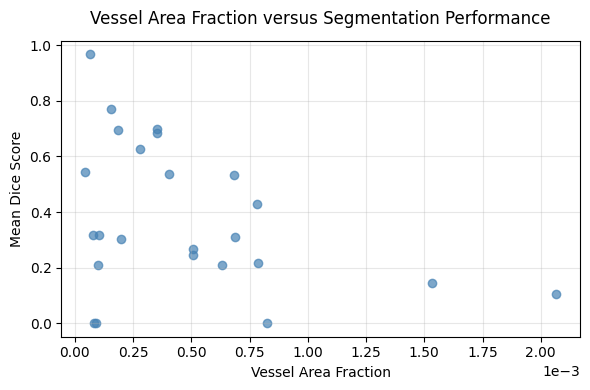

In [85]:
from matplotlib.ticker import ScalarFormatter

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(per_patient["vessel_area_frac"], per_patient["dice"], color="steelblue", alpha=0.7)

ax.set_xlabel("Vessel Area Fraction")
ax.set_ylabel("Mean Dice Score")
ax.set_title("Vessel Area Fraction versus Segmentation Performance", pad=12)

ax.ticklabel_format(axis="x", style="sci", scilimits=(0, 0))
ax.grid(alpha=0.3)

fig.tight_layout()